In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

2026-05-30 15:51:13.755226: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780156273.976777      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780156274.045261      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780156274.546796      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780156274.546856      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780156274.546859      58 computation_placer.cc:177] computation placer alr

Step 1: Machine Learning Models
Task 1.1 


In [3]:
df = pd.read_csv("/kaggle/input/datasets/aljowharahalrasheed/fainalpro/airline_route_profitability.csv")
df.head()
df.shape
df.isnull().sum()
df.shape

df["Ancillary_Revenue"] = df["Ancillary_Revenue"].fillna(df["Ancillary_Revenue"].median())
df["Catering_Cost"] = df["Catering_Cost"].fillna(df["Catering_Cost"].median())
df["Handling_Cost"] = df["Handling_Cost"].fillna(df["Handling_Cost"].median())
df.isnull().sum()

fuel_median = df["Fuel_Cost"].median()

df["Fuel_Consumption_Level"] = df["Fuel_Cost"].apply(
    lambda x: "High" if x >= fuel_median else "Low"
)

X = df.drop(columns=["Fuel_Consumption_Level", "Fuel_Cost", "Flight_Number", "Flight_Date"])
y = df["Fuel_Consumption_Level"]

X = pd.get_dummies(X)


['Aircraft_Capacity', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Ticket_Revenue', 'Ancillary_Revenue', 'Total_Revenue', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost', 'Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees', 'Sales_Distribution_Cost', 'Passenger_Service_Cost', 'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost', 'Total_Cost', 'Profit', 'Profit_Margin', 'Origin_DXB', 'Destination_AMM', 'Destination_BAH', 'Destination_BKK', 'Destination_BLR', 'Destination_BOM', 'Destination_CAI', 'Destination_CDG', 'Destination_CMB', 'Destination_DEL', 'Destination_DOH', 'Destination_FRA', 'Destination_HKG', 'Destination_HYD', 'Destination_IST', 'Destination_JED', 'Destination_JFK', 'Destination_KHI', 'Destination_KUL', 'Destination_KWI', 'Destination_LAX', 'Destination_LHE', 'Destination_LHR', 'Destination_MAA', 'Destination_MCT', 'Destination_MEL', 'Destination_ORD', 'Destination_RUH', 'Destination_SFO', 'Destination_SIN', 'Destination_SYD', 'Rou

In [ ]:
#I handled missing values by filling them with the median. Then I created the target variable (Fuel_Consumption_Level) based on the median fuel cost. 
#After that, I separated the dataset into features (X) and target (y), and converted categorical variables into numerical format using one-hot encoding.

In [ ]:
Step 1: Machine Learning Models
Task 1.2 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
y.value_counts()
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(6379, 99)
(1595, 99)
Fuel_Consumption_Level
Low     3190
High    3189
Name: count, dtype: int64
Fuel_Consumption_Level
High    798
Low     797
Name: count, dtype: int64


In [ ]:
# Split the dataset into training and testing sets (80% train, 20% test)
# Stratify is used to keep the same class distribution in both sets
# Then we check the shape of the data and the class balance in train and test sets

In [ ]:
Step 1: Machine Learning Models
Task 1.3

In [22]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label="High")
    rec = recall_score(y_test, y_pred, pos_label="High")
    f1 = f1_score(y_test, y_pred, pos_label="High")
    
    return acc, prec, rec, f1, y_pred
    #I created a function that outputs accuracy, precision, recall, and F1-score for all models.

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_acc, lr_prec, lr_rec, lr_f1, lr_pred = evaluate_model(lr, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_acc, rf_prec, rf_rec, rf_f1, rf_pred = evaluate_model(rf, X_test, y_test)

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_acc, knn_prec, knn_rec, knn_f1, knn_pred = evaluate_model(knn, X_test, y_test)

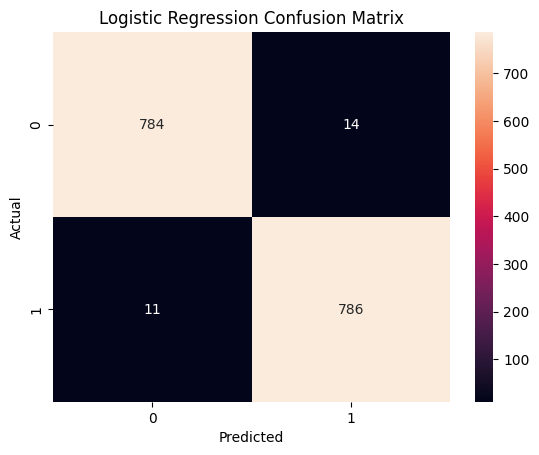

In [10]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

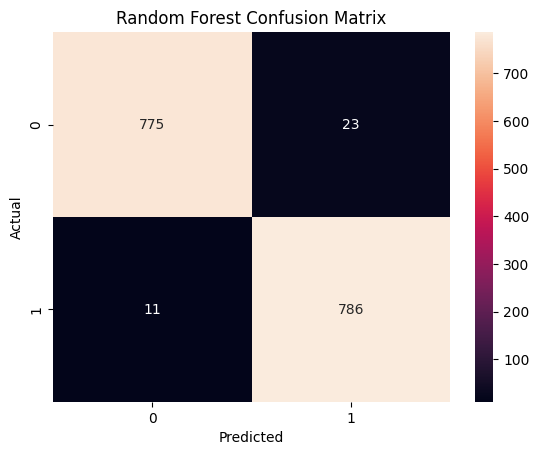

In [11]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

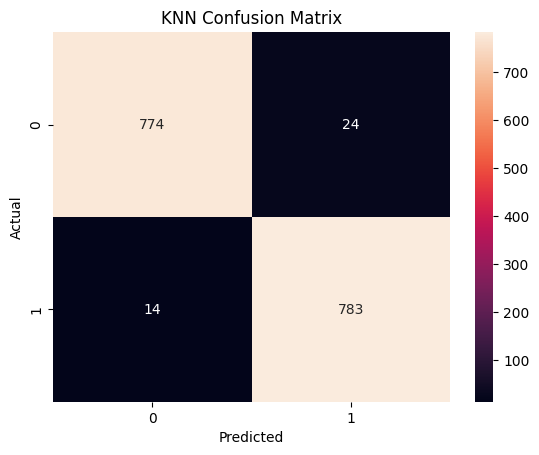

In [12]:
cm = confusion_matrix(y_test, knn_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [lr_acc, rf_acc, knn_acc],
    "Precision": [lr_prec, rf_prec, knn_prec],
    "Recall": [lr_rec, rf_rec, knn_rec],
    "F1-score": [lr_f1, rf_f1, knn_f1]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.984326,0.986164,0.982456,0.984306
1,Random Forest,0.978683,0.986005,0.971178,0.978535
2,KNN,0.976176,0.982234,0.969925,0.976040


In [ ]:
#Best Model: Logistic Regression
# Regression was selected as the best model because it achieved the highest Accuracy and F1-score (0.9843) among all models,
#with a strong balance between precision and recall, making it the most suitable model for this dataset.

Step 2: Neural Network
Task 2.1 


In [19]:
le = LabelEncoder()
y_train_nn = le.fit_transform(y_train)
y_test_nn = le.transform(y_test)

scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_test_nn = scaler.transform(X_test)


In [15]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_test_nn, y_test_nn),
    epochs=10,
    batch_size=32
)
#Built a neural network with Dense layers and Dropout, then trained it for 10 epochs.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-23 17:21:22.996179: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8912 - loss: 0.2556 - val_accuracy: 0.9737 - val_loss: 0.0624
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9706 - loss: 0.0741 - val_accuracy: 0.9774 - val_loss: 0.0538
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9715 - loss: 0.0669 - val_accuracy: 0.9762 - val_loss: 0.0526
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9756 - loss: 0.0566 - val_accuracy: 0.9787 - val_loss: 0.0493
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0572 - val_accuracy: 0.9799 - val_loss: 0.0501
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9716 - loss: 0.0639 - val_accuracy: 0.9749 - val_loss: 0.0511
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0585 - val_accuracy: 0.9787 - val_loss: 0.0496
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9686 - loss: 0.0648 - val_accuracy: 0.

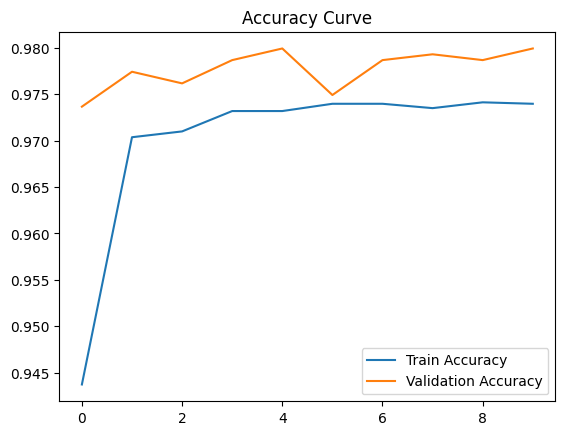

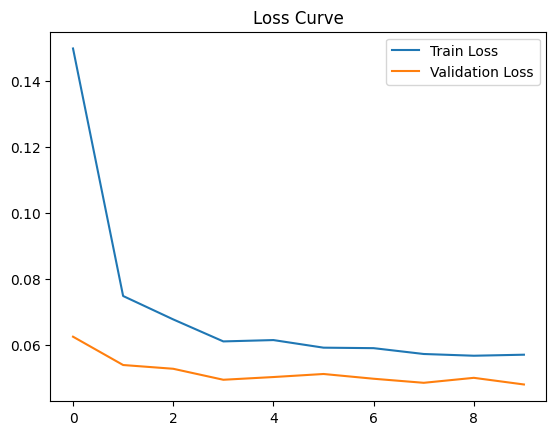

In [16]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [ ]:
Step 2: Neural Network
Task 2.2


In [17]:
y_pred_nn = model.predict(X_test_nn)
y_pred_nn = (y_pred_nn > 0.5).astype(int)

nn_acc = accuracy_score(y_test_nn, y_pred_nn)
nn_prec = precision_score(y_test_nn, y_pred_nn)
nn_rec = recall_score(y_test_nn, y_pred_nn)
nn_f1 = f1_score(y_test_nn, y_pred_nn)

print(nn_acc, nn_prec, nn_rec, nn_f1)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN", "Neural Network"],
    "Accuracy": [lr_acc, rf_acc, knn_acc, nn_acc],
    "Precision": [lr_prec, rf_prec, knn_prec, nn_prec],
    "Recall": [lr_rec, rf_rec, knn_rec, nn_rec],
    "F1-score": [lr_f1, rf_f1, knn_f1, nn_f1]
})

results

results.sort_values(by="F1-score", ascending=False)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
0.9799373040752352 0.9693251533742331 0.9912170639899623 0.9801488833746899


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.984326,0.986164,0.982456,0.984306
3,Neural Network,0.979937,0.969325,0.991217,0.980149
1,Random Forest,0.978683,0.986005,0.971178,0.978535
2,KNN,0.976176,0.982234,0.969925,0.976040


In [18]:
model_improved = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_improved.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_improved = model_improved.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_test_nn, y_test_nn),
    epochs=10,
    batch_size=32
)

y_pred_improved = model_improved.predict(X_test_nn)
y_pred_improved = (y_pred_improved > 0.5).astype(int)

acc_improved = accuracy_score(y_test_nn, y_pred_improved)
f1_improved = f1_score(y_test_nn, y_pred_improved)

print(acc_improved, f1_improved)
print("Original F1:", nn_f1)
print("Improved F1:", f1_improved)

#I improved the neural network by increasing the dropout rate to reduce overfitting.
#I compared the improved model with the original model using the F1-score. 
#The results showed a slight decrease in performance, which means the original model was already a good fit for this dataset.

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8077 - loss: 0.3942 - val_accuracy: 0.9687 - val_loss: 0.0736
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9626 - loss: 0.1036 - val_accuracy: 0.9718 - val_loss: 0.0586
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9655 - loss: 0.0861 - val_accuracy: 0.9768 - val_loss: 0.0551
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9649 - loss: 0.0806 - val_accuracy: 0.9768 - val_loss: 0.0529
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9692 - loss: 0.0718 - val_accuracy: 0.9768 - val_loss: 0.0512
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9694 - loss: 0.0696 - val_accuracy: 0.9774 - val_loss: 0.0502
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9717 - loss: 0.0659 - val_accuracy: 0.9781 - val_loss: 0.0505
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9724 - loss: 0.0623 - val_accuracy: 0.9774 - val_

In [5]:
features = [
    "Aircraft_Type",
    "Passengers",
    "Flight_Hours",
    "Total_Revenue",
    "Total_Cost",
    "Season",
    "Route_Category",
    "Demand_Level"
]

X = df[features]
y = df["Fuel_Consumption_Level"]

In [8]:
X = pd.get_dummies(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
import joblib

joblib.dump(model, "fuel_model.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['fuel_model.pkl']

In [12]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, pos_label="High"))

Accuracy: 0.9793103448275862
F1-score: 0.979179810725552


In [14]:
import os
print(os.listdir())

['fuel_model.pkl', '.virtual_documents']
